# **What is EDA?**

EDA stands for **Exploratory Data Analysis**. It's the process of examining and understanding a dataset before you start modeling or drawing conclusions. EDA involves summarizing the main characteristics of the data using visual methods (like histograms, box plots, scatter plots) and statistical techniques (like mean, median, standard deviation, correlation, etc.).

**Why EDA is Important:**

*Understanding the Data:*

Before building any model, you need to know what you're dealing with. EDA helps you understand the structure, patterns, and relationships in your data.

*Identifying Data Quality Issues:*

It helps detect:

1. Missing values

2. Outliers

3. Duplicates

4. Inconsistent data types

*Guiding Feature Engineering:*

EDA can show which features might be useful, which ones are redundant, and how variables interact with each other. This insight is crucial for creating meaningful features.

*Detecting Trends and Patterns:*

EDA reveals trends, seasonality, or clusters that can influence modeling decisions.

*Avoiding Wrong Assumptions:*

Looking at the raw data can prevent mistakes like assuming normal distribution when the data is skewed.

*Improving Model Performance:*

Better understanding of your data often leads to better preprocessing, which leads to more accurate models.

**Basic EDA Pipeline**

*   Explore the dataset.
*   Understand its structure and contents.
*   Discover patterns, relationships and anomalies.
*   Prepare it for further modeling or decision-making.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Stages of EDA**
####**Common EDA Techniques:**
#### 1.Descriptive Analysis
#### 2.Correlation Analysis
#### 3.Check imbalance in data

#### **Importing Required Python libraries**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


### **Load dataset**

In [33]:
dataset=pd.read_csv("/content/drive/MyDrive/cse422/software_quality_dataset.csv")

### **Summarize data**

In [34]:
dataset

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
0,356.0,31,144,69.567047,0.467561,2,Yes,4,Medium
1,227.0,15,104,131.844422,0.795643,2,No,5,High
2,9674.0,47,141,118.729027,0.316839,5,No,1,High
3,6967.0,42,107,194.397155,0.971883,5,Yes,3,Low
4,7954.0,35,114,69.202293,0.559417,1,No,8,Medium
...,...,...,...,...,...,...,...,...,...
1595,8883.0,40,31,54.863010,0.928920,3,Yes,8,Low
1596,2175.0,44,25,160.802073,0.696037,3,No,1,Low
1597,7872.0,39,47,121.382316,0.461773,3,No,2,High
1598,9660.0,24,55,75.626324,0.999547,2,No,6,Low


In [35]:
dataset.head(10)

,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Has_Unit_Tests,Code_Owner_Experience,Quality_Label
0,356.0,31,144,69.567047,0.467561,2,Yes,4,Medium
1,227.0,15,104,131.844422,0.795643,2,No,5,High
2,9674.0,47,141,118.729027,0.316839,5,No,1,High
3,6967.0,42,107,194.397155,0.971883,5,Yes,3,Low
4,7954.0,35,114,69.202293,0.559417,1,No,8,Medium
5,2305.0,38,120,164.299559,0.353860,5,No,6,Medium
6,8613.0,22,26,54.968552,0.355856,5,Yes,3,Medium
7,4479.0,5,149,88.060247,0.116470,7,Yes,7,High
8,8167.0,48,165,68.074588,0.723188,1,Yes,6,Low
9,6377.0,13,179,75.227914,0.798353,5,Yes,5,Medium


In [36]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))

Shape of the dataset is (1600, 9). This dataset contains 1600 rows and 9 columns.


### **Feature Names and its Datatypes**

In [37]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Lines_of_Code          1520 non-null   float64
 1   Cyclomatic_Complexity  1600 non-null   int64  
 2   Num_Functions          1600 non-null   int64  
 3   Code_Churn             1520 non-null   float64
 4   Comment_Density        1520 non-null   float64
 5   Num_Bugs               1600 non-null   int64  
 6   Has_Unit_Tests         1600 non-null   object 
 7   Code_Owner_Experience  1600 non-null   int64  
 8   Quality_Label          1600 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 112.6+ KB


### **Data Spliting**
#### Select and separately store Numerical and Categorical features in different variables.

In [38]:
##Selecting numerical features
numerical_data = dataset.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 7 numerical features: 

['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn', 'Comment_Density', 'Num_Bugs', 'Code_Owner_Experience']


In [39]:
#Selecting categoricalfeatures
categorical_data=dataset.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

There are 2 numerical features: 

['Has_Unit_Tests', 'Quality_Label']


### **Descriptive Analysis**
#### In descriptive Analysis we analysis each variable separately to get inference about the feature.
### **Summary satistics of Numerical Features**

In [40]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Lines_of_Code,1520.0,4939.269737,2867.248259,106.000000,2490.750000,4860.000000,7455.250000,9998.000000
Cyclomatic_Complexity,1600.0,25.076875,13.879621,1.000000,13.000000,25.000000,37.000000,49.000000
Num_Functions,1600.0,103.178125,55.503710,5.000000,56.000000,104.000000,152.000000,199.000000
Code_Churn,1520.0,102.572291,50.546329,-64.283310,67.509852,104.007452,138.619113,295.139936
Comment_Density,1520.0,0.549370,0.256137,0.101037,0.337596,0.542108,0.765766,0.999976
Num_Bugs,1600.0,2.934375,1.715928,0.000000,2.000000,3.000000,4.000000,10.000000
Code_Owner_Experience,1600.0,5.045000,2.559701,1.000000,3.000000,5.000000,7.000000,9.000000


### **Summary satistics of Categorical features**

In [41]:
# Transposed stats for categorical features

categorical_data.describe().T

,count,unique,top,freq
Has_Unit_Tests,1600,2,No,820
Quality_Label,1600,3,High,566


### **Variance of each numerical features**

In [42]:
numerical_data.var()

,0
Lines_of_Code,8.221113e+06
Cyclomatic_Complexity,1.926439e+02
Num_Functions,3.080662e+03
Code_Churn,2.554931e+03
Comment_Density,6.560604e-02
Num_Bugs,2.944409e+00
Code_Owner_Experience,6.552070e+00


### **Skew in numerical features**

📐 What is Skewness?
Skewness measures the asymmetry of the distribution of a dataset.

Skewness = 0 → Perfectly symmetrical (e.g., normal distribution)

Skewness < 0 → Left-skewed (long tail on the left)

Skewness > 0 → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

📊 Interpretation of Skewness Values:

Skewness Value	Interpretation

~ 0	Symmetrical (normal-ish)

0 to ±0.5	Fairly symmetrical

±0.5 to ±1	Moderately skewed

greater than ±1	Highly skewed

In [43]:
numerical_data.skew()

,0
Lines_of_Code,0.055175
Cyclomatic_Complexity,0.015461
Num_Functions,-0.034194
Code_Churn,-0.113186
Comment_Density,0.004302
Num_Bugs,0.667812
Code_Owner_Experience,-0.042283


###**Skewness Interpretation**

*ID (0.448): Fairly symmetrical – no strong skew.

*CREDIT_SCORE (-0.226): Slightly left-skewed – not a concern.

*VEHICLE_OWNERSHIP (-1.729): Highly left-skewed – most values are 1 or 0; likely a categorical variable.

*MARRIED (-0.341): Slightly left-skewed – not a big issue.

*CHILDREN (-0.080): Almost symmetrical – no transformation needed.

*POSTAL_CODE (2.987): Strong right-skew – likely due to many unique codes; should be treated as categorical.

*ANNUAL_MILEAGE (-0.510): Moderately left-skewed – may benefit from transformation.

*SPEEDING_VIOLATIONS (3.900): Highly right-skewed – most people have few or no violations; some have many.

*DUIS (5.609): Extremely right-skewed – majority have zero DUIs; a few have multiple.

*PAST_ACCIDENTS (4.346): Strong right-skew – most have few accidents; some have many.

*OUTCOME (0.313): Fairly symmetrical – distribution looks balanced.



### **Histograms and Box Plot**
#### To find the distributions and outlier in the each feature

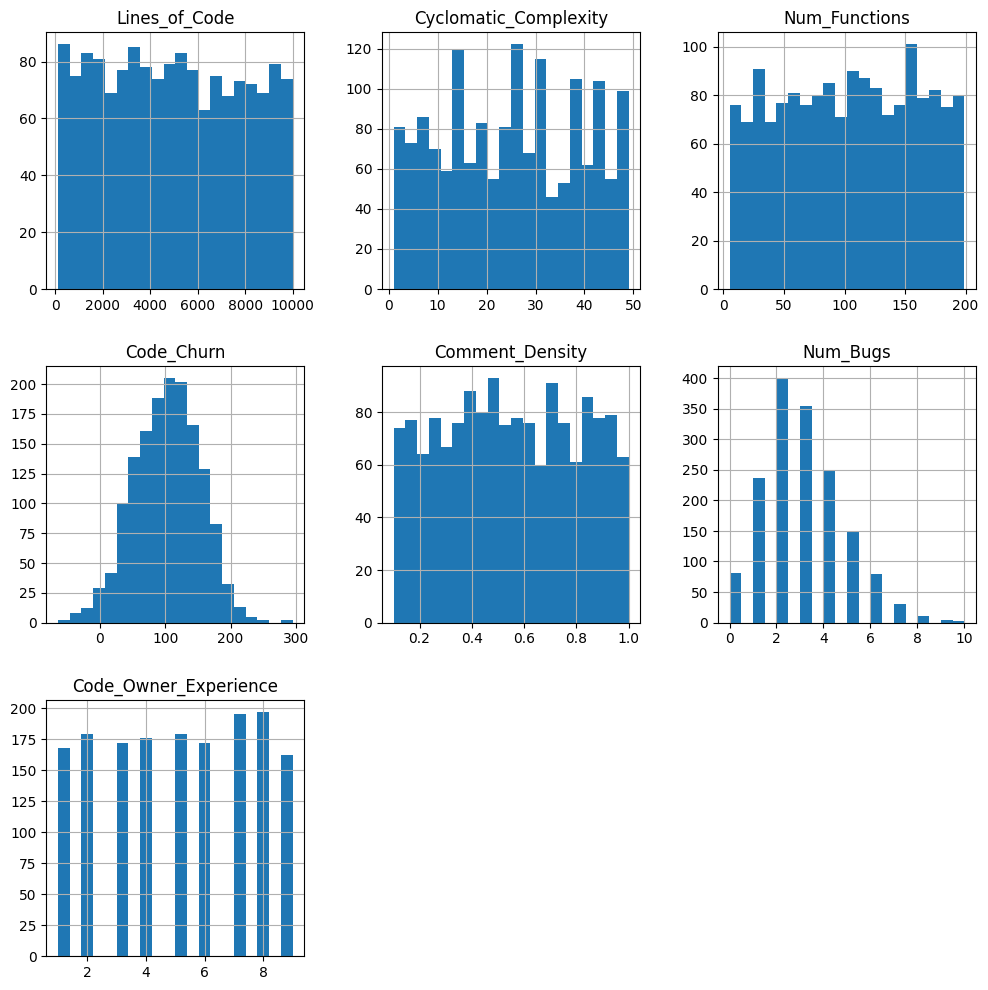

In [44]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

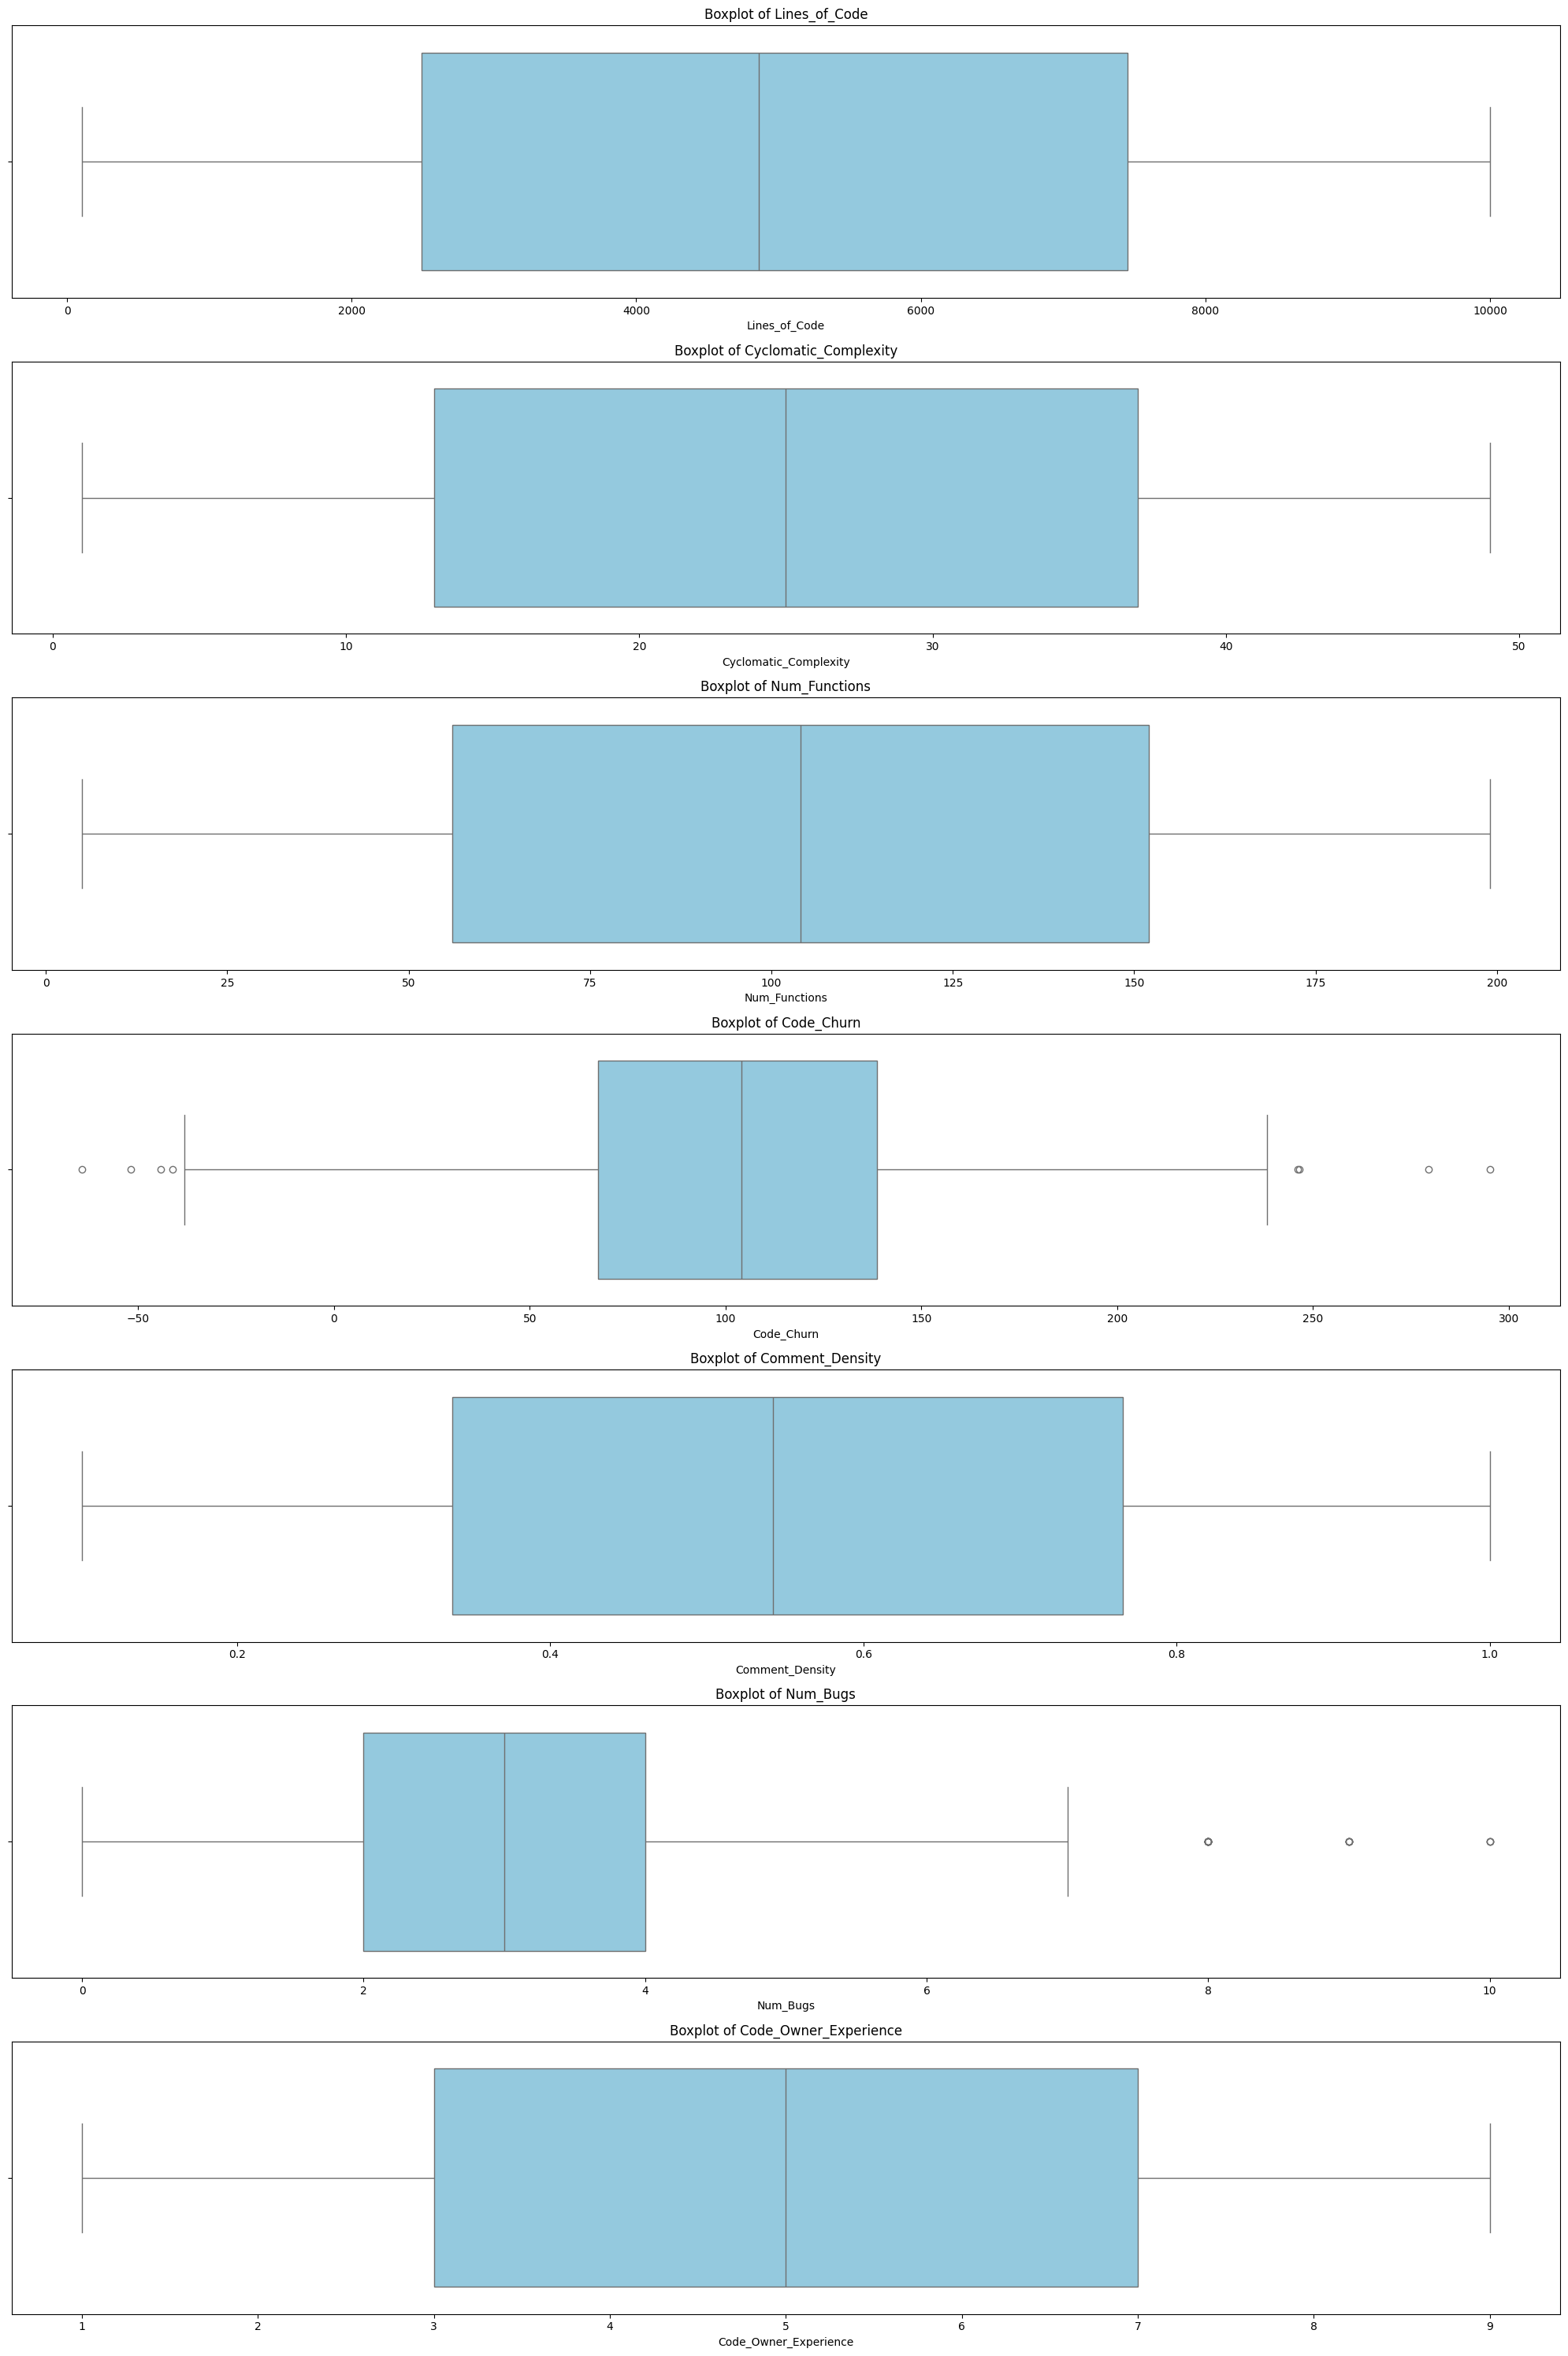

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


### **Number Unique values in each feature**

In [46]:
numerical_data.nunique()

,0
Lines_of_Code,1413
Cyclomatic_Complexity,49
Num_Functions,195
Code_Churn,1520
Comment_Density,1520
Num_Bugs,11
Code_Owner_Experience,9


### **Missing Values**

In [47]:
numerical_data.isnull().sum()

,0
Lines_of_Code,80
Cyclomatic_Complexity,0
Num_Functions,0
Code_Churn,80
Comment_Density,80
Num_Bugs,0
Code_Owner_Experience,0


### **Categorical Features**


#### **No of unique values in each categorical feature**

In [48]:
# unique values counts
unique_counts=categorical_data.nunique()
print(unique_counts)

Has_Unit_Tests    2
Quality_Label     3
dtype: int64


### **Barplot of unique value counts in every categorical features**

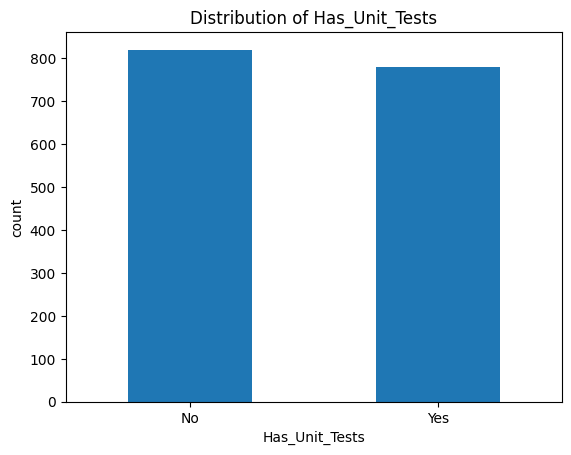

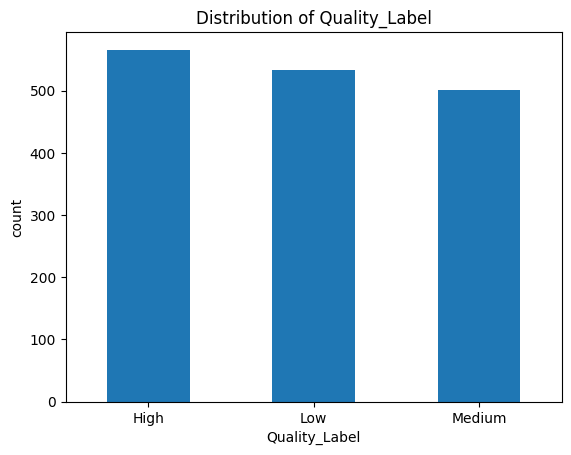

In [49]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

### **Correlation Analysis**
### **Correlation matrix of whole dataset**

In [50]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix


,Lines_of_Code,Cyclomatic_Complexity,Num_Functions,Code_Churn,Comment_Density,Num_Bugs,Code_Owner_Experience
Lines_of_Code,1.000000,0.046746,-0.026398,0.003710,0.019014,-0.029780,0.015243
Cyclomatic_Complexity,0.046746,1.000000,-0.005937,-0.022347,0.041138,-0.076648,-0.019038
Num_Functions,-0.026398,-0.005937,1.000000,-0.005121,-0.002924,0.007963,0.011028
Code_Churn,0.003710,-0.022347,-0.005121,1.000000,0.010962,-0.015592,0.022090
Comment_Density,0.019014,0.041138,-0.002924,0.010962,1.000000,-0.045190,0.028216
Num_Bugs,-0.029780,-0.076648,0.007963,-0.015592,-0.045190,1.000000,-0.008013
Code_Owner_Experience,0.015243,-0.019038,0.011028,0.022090,0.028216,-0.008013,1.000000


### **Correlation Heatmap plot of whole dataset**

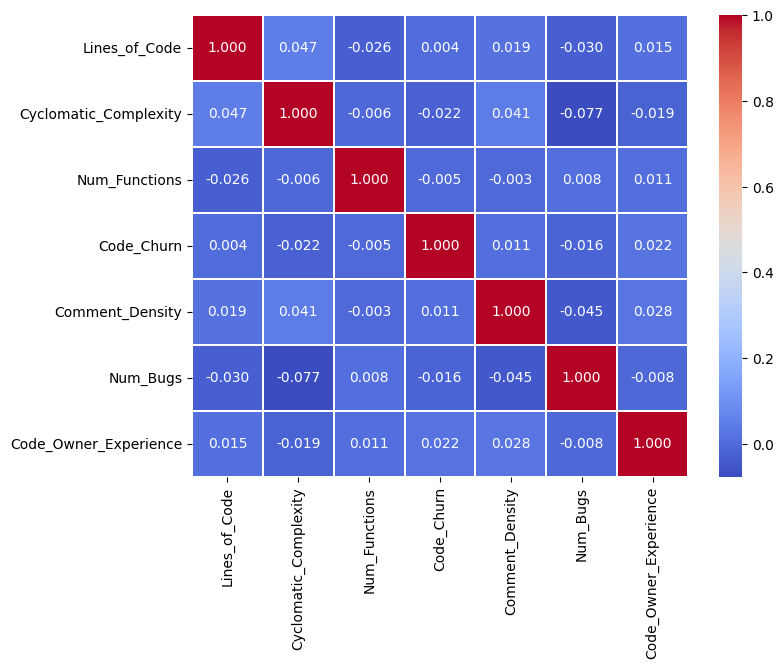

In [51]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

### **Generating correlation plot between features and target variable using different method**

### **Some Correlation techniques**
**🔹 1. Pearson Correlation Coefficient**

📌 Purpose:
Measures the linear relationship between two continuous (numeric) variables.

💡 Characteristics:

Value ranges from -1 to +1

+1: Perfect positive linear correlation

-1: Perfect negative linear correlation

0: No linear relationship

Sensitive to outliers.

✅ Used For:
Finding how variables like CREDIT_SCORE, ANNUAL_MILEAGE, DUIS, etc., relate to each other or the OUTCOME.

**🔹 2. Cramér's V (for Categorical-Categorical Correlation)**

📌 Purpose:
Measures the association between two categorical variables.

💡 Characteristics:

Value ranges from 0 to 1

0: No association

1: Perfect association

Based on Chi-Square statistics

✅ Used For:
Checking relationships between columns like GENDER, EDUCATION, INCOME, TYPE_OF_VEHICLE, etc.

**🔹 3. Point-Biserial Correlation (for Continuous vs Binary)**

📌 Purpose:
A special case of Pearson correlation used when one variable is binary (e.g., 0 or 1) and the other is continuous.

💡 Characteristics:

Essentially checks if the means of the two binary groups are different in a statistically linear sense.

✅ Used For:
Relating binary target OUTCOME with features like:

* CREDIT_SCORE

* ANNUAL_MILEAGE

* PAST_ACCIDENTS

* etc.

**🔹 4. Spearman Rank Correlation**

📌 Purpose:
Measures monotonic relationships between two variables — whether linear or non-linear.

💡 Characteristics:

Uses rank values rather than raw data.

Value range: -1 to +1

Less sensitive to outliers than Pearson

Ideal for ordinal data or when relationships are not linear.

✅ Use Case:
DRIVING_EXPERIENCE (ordinal) vs OUTCOME

AGE group vs CREDIT_SCORE

**🔹 5. Kendall’s Tau**

📌 Purpose:
Also measures ordinal association between two variables using pairwise concordance.

💡 Characteristics:

More conservative than Spearman

Interprets strength of monotonic relationships

Value range: -1 to +1

Better for smaller datasets or when many ties exist in the ranks

✅ Use Case:
Similar to Spearman — works well with ranks and ties.

#### **Correlation plot between numerical features and target**

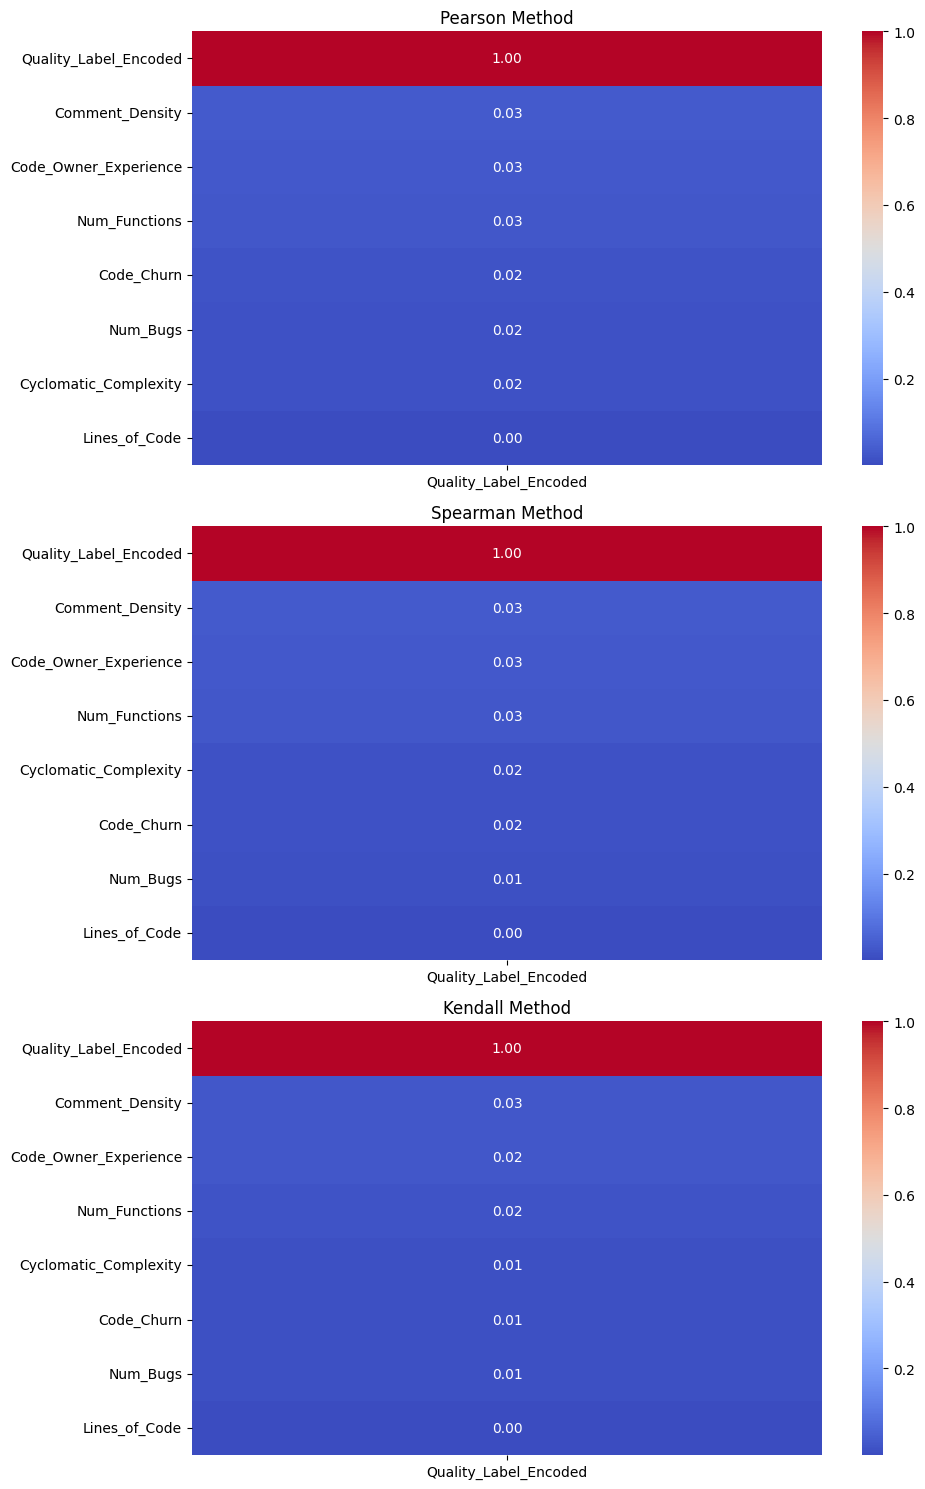

In [52]:




le = LabelEncoder()
dataset['Quality_Label_Encoded'] = le.fit_transform(dataset['Quality_Label'])


numerical_data = dataset.select_dtypes(include=['number'])


fig, ax = plt.subplots(3, 1, figsize=(10, 15))

corr1 = numerical_data.corr(method='pearson')[['Quality_Label_Encoded']].sort_values(by='Quality_Label_Encoded', ascending=False)
corr2 = numerical_data.corr(method='spearman')[['Quality_Label_Encoded']].sort_values(by='Quality_Label_Encoded', ascending=False)
corr3 = numerical_data.corr(method='kendall')[['Quality_Label_Encoded']].sort_values(by='Quality_Label_Encoded', ascending=False)

ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')


sns.heatmap(corr1, ax=ax[0], annot=True, cmap='coolwarm', fmt=".2f")
sns.heatmap(corr2, ax=ax[1], annot=True, cmap='coolwarm', fmt=".2f")
sns.heatmap(corr3, ax=ax[2], annot=True, cmap='coolwarm', fmt=".2f")

plt.tight_layout()
plt.show()

### **Check imbalance in the data**
#### We have classification problem so we need to check the balance of the given data.

In [53]:






class_counts = dataset.groupby("Quality_Label").size()


columns = ['Outcome', 'Count', 'Percentage']
outcome = class_counts.index.tolist()
count = class_counts.values.tolist()
percentage = []


total_instances = len(dataset)
for c in count:
    percent = (c / total_instances) * 100
    percentage.append(percent)

imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)), columns=columns)


print(imbalance_df)

  Outcome  Count  Percentage
0    High    566     35.3750
1     Low    533     33.3125
2  Medium    501     31.3125


### **Barplot of Outcome vs Percentage**

/tmp/ipykernel_4295/2342748831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imbalance_df, x='outcome', y='percentage', palette='viridis')


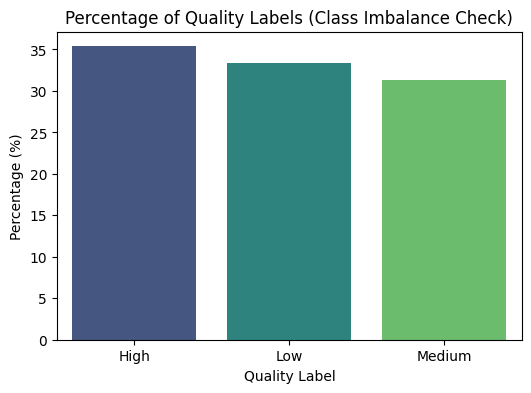

In [54]:


import seaborn as sns
import matplotlib.pyplot as plt

imbalance_df.columns = [col.lower() for col in imbalance_df.columns]

plt.figure(figsize=(6, 4))
sns.barplot(data=imbalance_df, x='outcome', y='percentage', palette='viridis')


plt.title('Percentage of Quality Labels (Class Imbalance Check)')
plt.xlabel('Quality Label')
plt.ylabel('Percentage (%)')

plt.show()

### **Observation**
#### * Based on the above grouping, It shows that around **58%** of instances consists OUTCOME value '0' and **42%** of instances consists OUTCOME values '1'
#### * There is imbalance between two classes **(approx 16% difference)**

###**Common Solutions to Class Imbalance:**
✅ 1. Resampling Techniques


a. Oversampling (Minority Class)

Increases the number of samples in the minority class.

Tools: SMOTE, ADASYN, or simple random oversampling.

b. Undersampling (Majority Class)

Reduces the number of samples in the majority class.

Can risk losing important information.

c. Hybrid Methods

Combines both oversampling and undersampling for better balance.

Example: SMOTE-ENN, SMOTE-Tomek Links.

✅ 2. Use of Class Weights

Assign higher penalty to misclassifying minority class. Many ML algorithms support this:

class_weight='balanced' in LogisticRegression, RandomForest, SVM, etc.

In deep learning: use weighted loss functions (e.g., weighted Cross Entropy).

✅ 3. Synthetic Data Generation

Create artificial data points for minority class.

SMOTE (Synthetic Minority Over-sampling Technique) is the most popular method.

ADASYN is an advanced version of SMOTE that adapts based on the data distribution.

✅ 4. Anomaly Detection Framing

If the minority class is extremely rare, consider treating it as an anomaly detection problem.

✅ 5. Ensemble Methods

Bagging/Boosting techniques (e.g., Balanced Random Forest, XGBoost with scale_pos_weight) can perform well on imbalanced data.

These methods can learn patterns even in imbalanced settings by focusing on hard-to-classify instances.

✅ 6. Data Augmentation (for Images, Text, etc.)

Apply transformations to minority class data to artificially expand it (for example, rotate/flip images).

✅ 7. Evaluation Metrics Adjustment

Accuracy can be misleading in imbalanced data.

Use:

Precision, Recall, F1-Score

ROC-AUC

PR AUC (for very imbalanced datasets)


### **Data visualization**
#### Some other visualizations of features to get more insights

### **Density plots of numerical features**

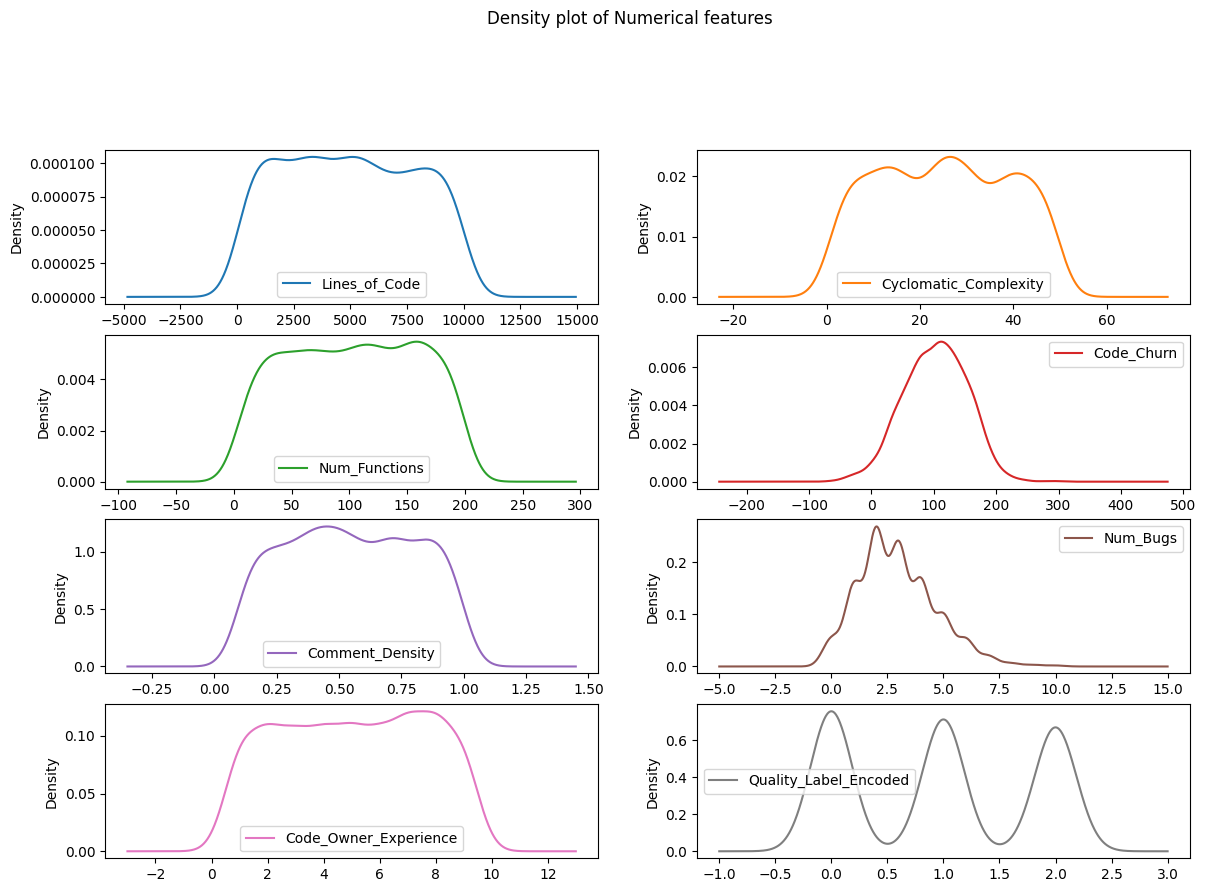

In [55]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

### **SUMMARY**
#### Performed various exploratory data analysis techniques such as univariate, correlation, visualization on the given vehicle insurance dataset also found moderate imbalance in the given dataset. From the insights acquired through the analysis we will make better decisions when we do Machine learning model development.

Missing value handeling

In [56]:

dataset['Lines_of_Code'] = dataset['Lines_of_Code'].fillna(dataset['Lines_of_Code'].median())
dataset['Code_Churn'] = dataset['Code_Churn'].fillna(dataset['Code_Churn'].median())
dataset['Comment_Density'] = dataset['Comment_Density'].fillna(dataset['Comment_Density'].median())

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['Has_Unit_Tests'] = le.fit_transform(dataset['Has_Unit_Tests'])
dataset['Quality_Label'] = le.fit_transform(dataset['Quality_Label'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_raw = dataset.drop('Quality_Label', axis=1)
y = dataset['Quality_Label']
X_scaled = scaler.fit_transform(X_raw)

Data splliting (before train)

In [57]:

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

Train part (3 model at a time)

In [58]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, log_loss
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

knn_model = KNeighborsClassifier()
dt_model = DecisionTreeClassifier(random_state=42)
nn_model = MLPClassifier(random_state=42, max_iter=1000)


kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {'KNN': knn_model, 'Decision Tree': dt_model, 'Neural Network': nn_model}


Model evulation

In [59]:

fold_results = {name: {'accuracy': [], 'loss': []} for name in models.keys()}
overall_metrics = []

for name, model in models.items():
    print(f"\n--- Processing Model: {name} ---")


    for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled), start=1):
        X_tr, X_val = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_val = y[train_idx], y[test_idx]

        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)
        y_prob_val = model.predict_proba(X_val)

        acc = accuracy_score(y_val, y_pred_val)
        loss = log_loss(y_val, y_prob_val)

        fold_results[name]['accuracy'].append(acc)
        fold_results[name]['loss'].append(loss)


        print(f"Fold {fold}: Accuracy = {acc:.4f}, Loss = {loss:.4f}")


    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)


    f_acc = accuracy_score(y_test, y_pred)
    f_prec = precision_score(y_test, y_pred, average='macro')
    f_rec = recall_score(y_test, y_pred, average='macro')
    f_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')


    print(f"\nFinal Scores for {name}:")
    print(f"  Precision: {f_prec:.4f}")
    print(f"  Recall:    {f_rec:.4f}")
    print(f"  AUC Score: {f_auc:.4f}")
    print("-" * 30)

    overall_metrics.append({
        'Model': name,
        'Accuracy': f_acc,
        'Precision': f_prec,
        'Recall': f_rec,
        'AUC': f_auc
    })

import pandas as pd
print("\n--- Overall Model Comparison Table ---")
print(pd.DataFrame(overall_metrics))


--- Processing Model: KNN ---
Fold 1: Accuracy = 0.9531, Loss = 0.2366
Fold 2: Accuracy = 0.9250, Loss = 0.2733
Fold 3: Accuracy = 0.9187, Loss = 0.3888
Fold 4: Accuracy = 0.9437, Loss = 0.2668
Fold 5: Accuracy = 0.9344, Loss = 0.2686

Final Scores for KNN:
  Precision: 0.9447
  Recall:    0.9427
  AUC Score: 0.9931
------------------------------

--- Processing Model: Decision Tree ---
Fold 1: Accuracy = 1.0000, Loss = 0.0000
Fold 2: Accuracy = 1.0000, Loss = 0.0000
Fold 3: Accuracy = 1.0000, Loss = 0.0000
Fold 4: Accuracy = 1.0000, Loss = 0.0000
Fold 5: Accuracy = 1.0000, Loss = 0.0000

Final Scores for Decision Tree:
  Precision: 1.0000
  Recall:    1.0000
  AUC Score: 1.0000
------------------------------

--- Processing Model: Neural Network ---
Fold 1: Accuracy = 1.0000, Loss = 0.0043
Fold 2: Accuracy = 1.0000, Loss = 0.0043
Fold 3: Accuracy = 1.0000, Loss = 0.0047
Fold 4: Accuracy = 1.0000, Loss = 0.0048
Fold 5: Accuracy = 1.0000, Loss = 0.0046

Final Scores for Neural Network:

Model compare

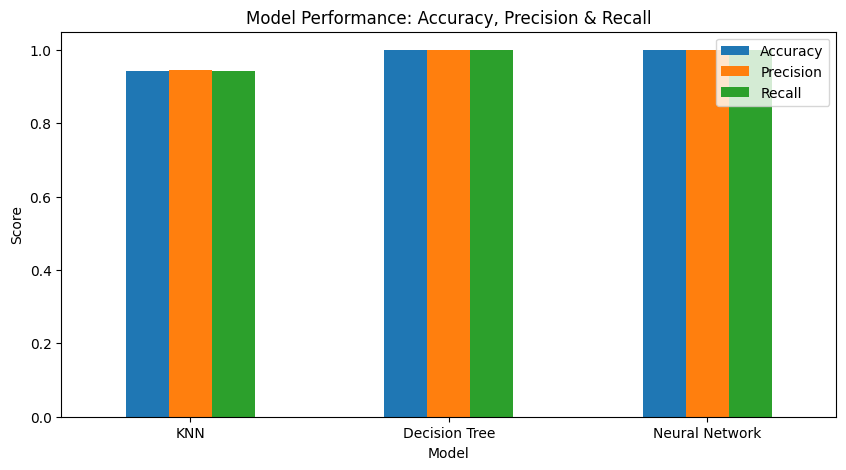

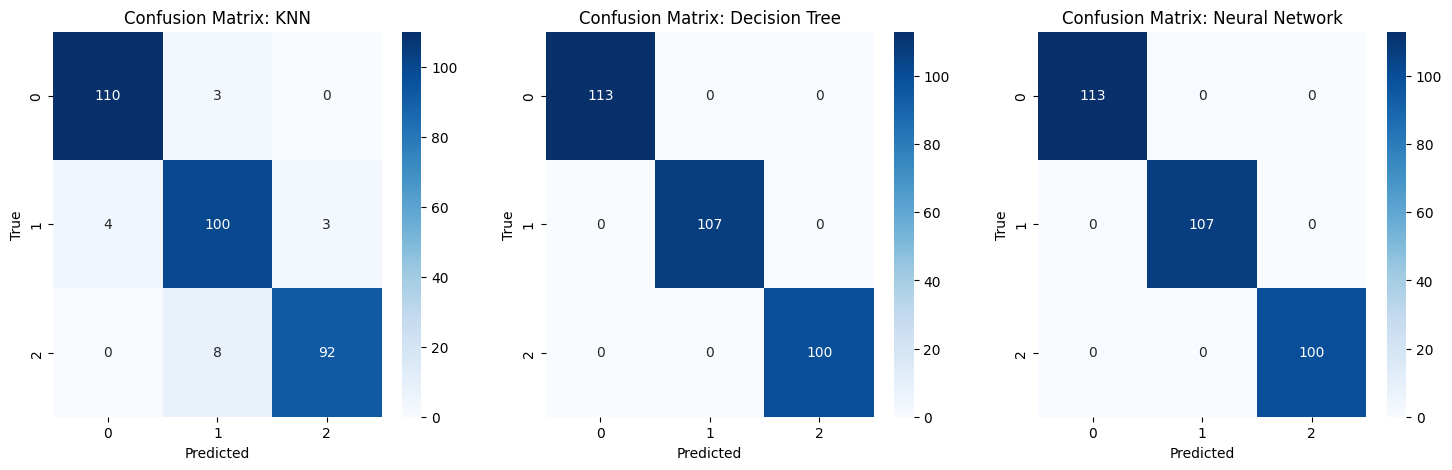

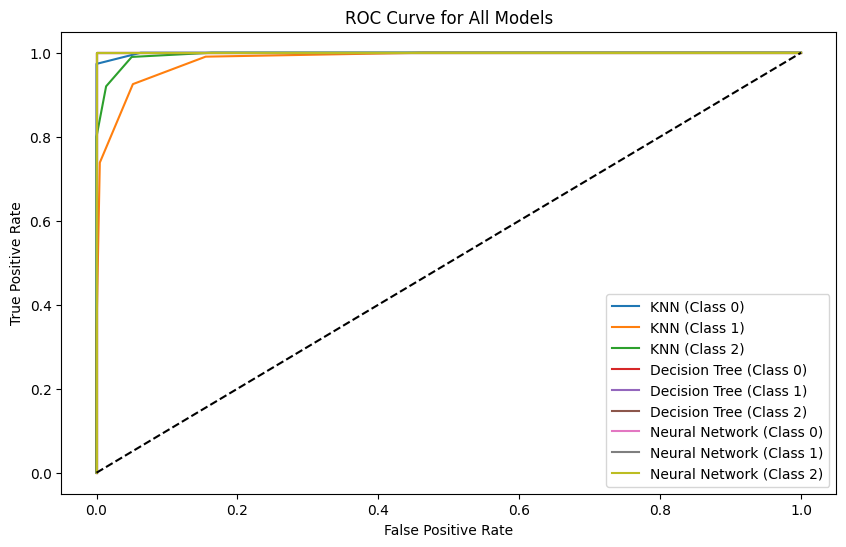

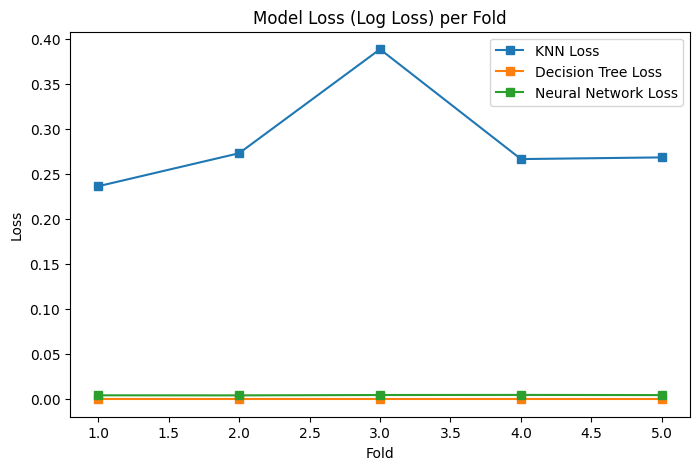


--- Final Model Comparison Summary ---
            Model  Accuracy  Precision    Recall       AUC
0             KNN   0.94375   0.944745  0.942677  0.993064
1   Decision Tree   1.00000   1.000000  1.000000  1.000000
2  Neural Network   1.00000   1.000000  1.000000  1.000000


In [60]:

df_metrics = pd.DataFrame(overall_metrics)
df_metrics.plot(x='Model', y=['Accuracy', 'Precision', 'Recall'], kind='bar', figsize=(10, 5))
plt.title('Model Performance: Accuracy, Precision & Recall')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.show()


plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)
    for j in range(len(np.unique(y))):
        fpr, tpr, _ = roc_curve(y_test == j, y_proba[:, j])
        plt.plot(fpr, tpr, label=f'{name} (Class {j})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for name, results in fold_results.items():
    plt.plot(range(1, 6), results['loss'], marker='s', label=f'{name} Loss')
plt.title('Model Loss (Log Loss) per Fold')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\n--- Final Model Comparison Summary ---")
print(df_metrics)